# Sentiment Analysis of Strava Reviews from Apple App Store


In [17]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns

In [8]:


df_reviews = pd.read_csv("data/strava_reviews.csv")
display(df_reviews.head(10), df_reviews.describe(), df_reviews.shape)

,review,rating,date
0,Awsomeeee,5,2026-04-05T20:48:27-07:00
1,Paid for a subscription and it never unlocked ...,1,2026-04-05T20:25:07-07:00
2,I was immediately charged $80 for what was sup...,1,2026-04-05T18:43:31-07:00
3,The majority of the app has turned into a sche...,1,2026-04-05T12:55:19-07:00
4,Love the app but I CANNOT STAND how much it bu...,3,2026-04-04T15:41:38-07:00
5,I connected my heart rate monitor to the app. ...,1,2026-04-04T11:20:49-07:00
6,freetrailfretrail freetrailfretrail freetrailf...,1,2026-04-04T07:27:25-07:00
7,Every year Strava takes away at least one feat...,1,2026-04-04T05:51:20-07:00
8,I’ve had Strava for years and loved it. It was...,1,2026-04-03T23:10:11-07:00
9,Longtime member of Strava and lately I don’t k...,5,2026-04-02T17:13:59-07:00


,rating
count,490.000000
mean,2.965306
std,1.750495
min,1.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,5.000000


(490, 3)

# Visualizing App Reviews

With 490 review samples, the bar plot below indicates a relatively balanced distribution of ratings, particularly between 1-star and 5-star reviews, suggesting the dataset contains a strong mix of negative and positive sentiment.

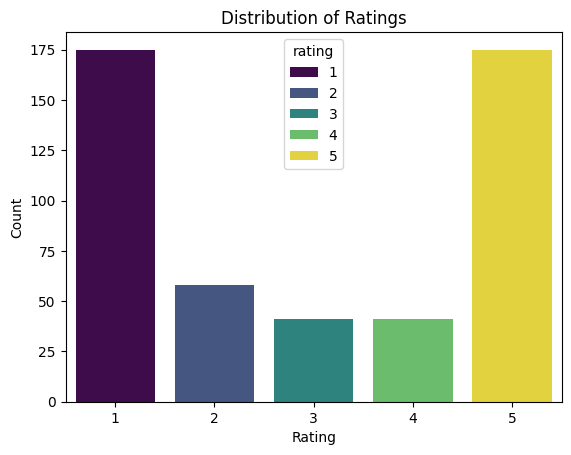

In [26]:
df_reviews_counts = df_reviews["rating"].value_counts().sort_index()
sns.barplot(x=df_reviews_counts.index, y=df_reviews_counts.values, hue=df_reviews_counts.index, palette="viridis")
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

The next visualization displays the average review word length by rating. The results indicate that lower-rated reviews (1–3 stars) generally contain more words on average than higher-rated reviews, suggesting that negative feedback tends to be more detailed and descriptive.

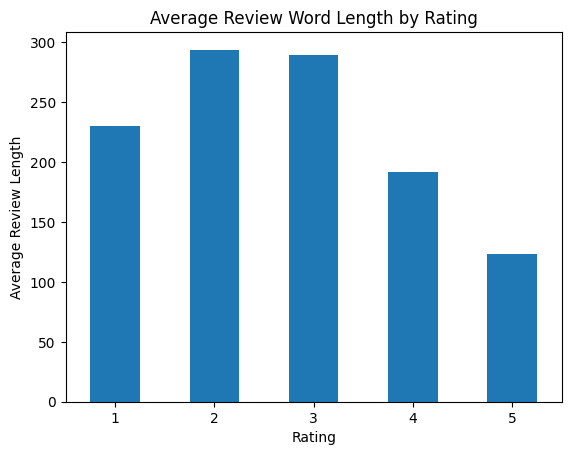

In [16]:
df_reviews["review_length"] = df_reviews["review"].str.len()

df_reviews.groupby("rating")["review_length"].mean().plot(kind="bar")
plt.title("Average Review Word Length by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Review Length")
plt.xticks(rotation=0)
plt.show()

This boxplot visualizes the distribution of review word lengths by rating. It highlights differences in median length, spread, and variability across ratings, while also showing outlier reviews that are unusually short or long compared to the rest of the data.

<Axes: xlabel='rating', ylabel='review_length'>

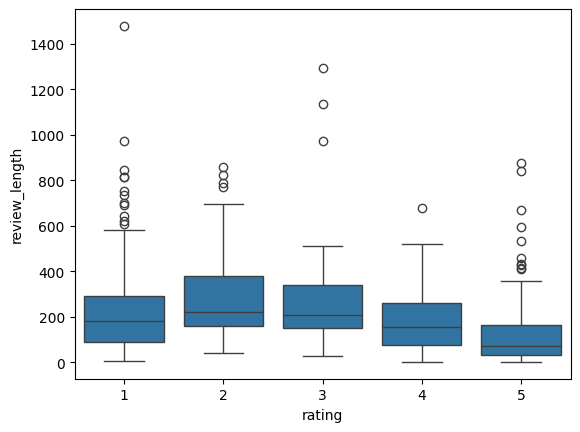

In [18]:
sns.boxplot(x="rating", y="review_length", data=df_reviews)

The visualization below shows the number of reviews over time which, highlights monthly trends in review volume. April shows a lower count compared to other months, which is expected since the dataset only includes data from the first week of the month.

C:\Users\gclou\AppData\Local\Temp\ipykernel_26284\2654307536.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_reviews.groupby(df_reviews["date"].dt.to_period("M"))["rating"].count().plot()


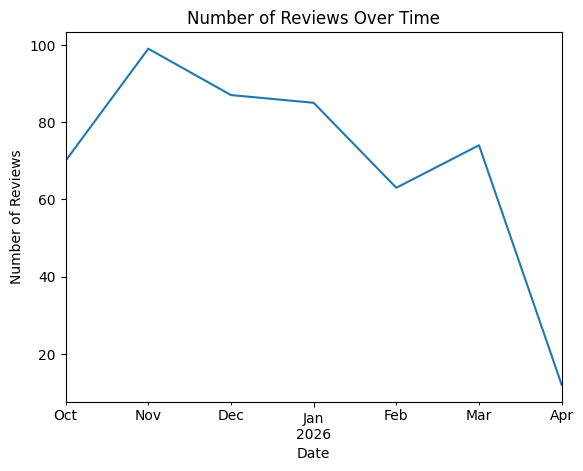

In [20]:
df_reviews["date"] = pd.to_datetime(df_reviews["date"])

df_reviews.groupby(df_reviews["date"].dt.to_period("M"))["rating"].count().plot()
plt.title("Number of Reviews Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.show()